In [6]:
# ── Cell 1: Import ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/restaurant_data.csv', sep=';')
print("Shape:", df.shape)
print("\nKolom:", list(df.columns))

Shape: (8368, 17)

Kolom: ['Name', 'Location', 'Cuisine', 'Rating', 'Seating Capacity', 'Average Meal Price', 'Marketing Budget', 'Social Media Followers', 'Chef Experience Years', 'Number of Reviews', 'Avg Review Length', 'Ambience Score', 'Service Quality Score', 'Parking Availability', 'Weekend Reservations', 'Weekday Reservations', 'Revenue']


In [7]:
# ── Cell 2: Cek data ──
print("Missing values:")
print(df.isnull().sum())
print("\nTipe data:")
print(df.dtypes)
print("\nStatistik:")
print(df.describe())

Missing values:
Name                      0
Location                  0
Cuisine                   0
Rating                    0
Seating Capacity          0
Average Meal Price        0
Marketing Budget          0
Social Media Followers    0
Chef Experience Years     0
Number of Reviews         0
Avg Review Length         0
Ambience Score            0
Service Quality Score     0
Parking Availability      0
Weekend Reservations      0
Weekday Reservations      0
Revenue                   0
dtype: int64

Tipe data:
Name                       object
Location                   object
Cuisine                    object
Rating                    float64
Seating Capacity            int64
Average Meal Price        float64
Marketing Budget            int64
Social Media Followers      int64
Chef Experience Years       int64
Number of Reviews           int64
Avg Review Length          object
Ambience Score            float64
Service Quality Score     float64
Parking Availability       object
Weekend

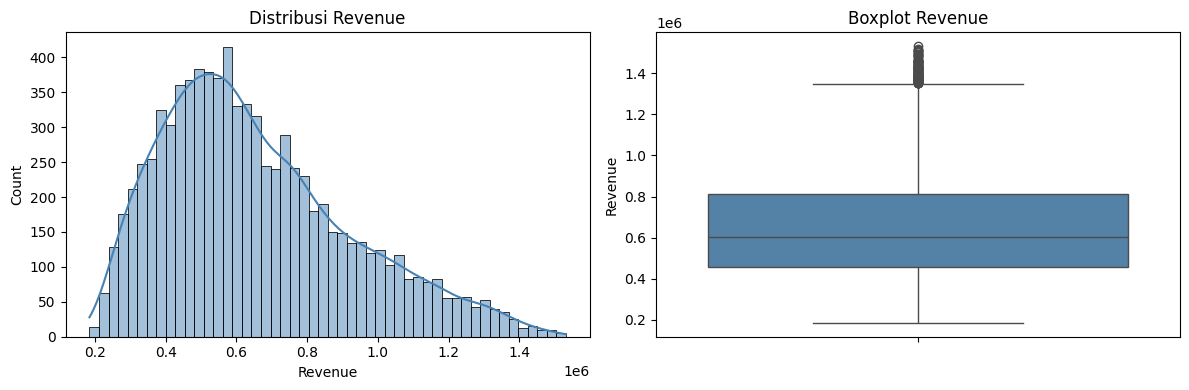

Min    : 184,709
Median : 604,242
Mean   : 656,071
Max    : 1,531,868


In [8]:
# ── Cell 3: Distribusi Revenue (Target) ──
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['Revenue'], bins=50, kde=True, color='steelblue')
plt.title('Distribusi Revenue')
plt.xlabel('Revenue')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Revenue'], color='steelblue')
plt.title('Boxplot Revenue')

plt.tight_layout()
plt.savefig('../reports/figures/distribusi_revenue.png', dpi=150)
plt.show()

print(f"Min    : {df['Revenue'].min():,.0f}")
print(f"Median : {df['Revenue'].median():,.0f}")
print(f"Mean   : {df['Revenue'].mean():,.0f}")
print(f"Max    : {df['Revenue'].max():,.0f}")

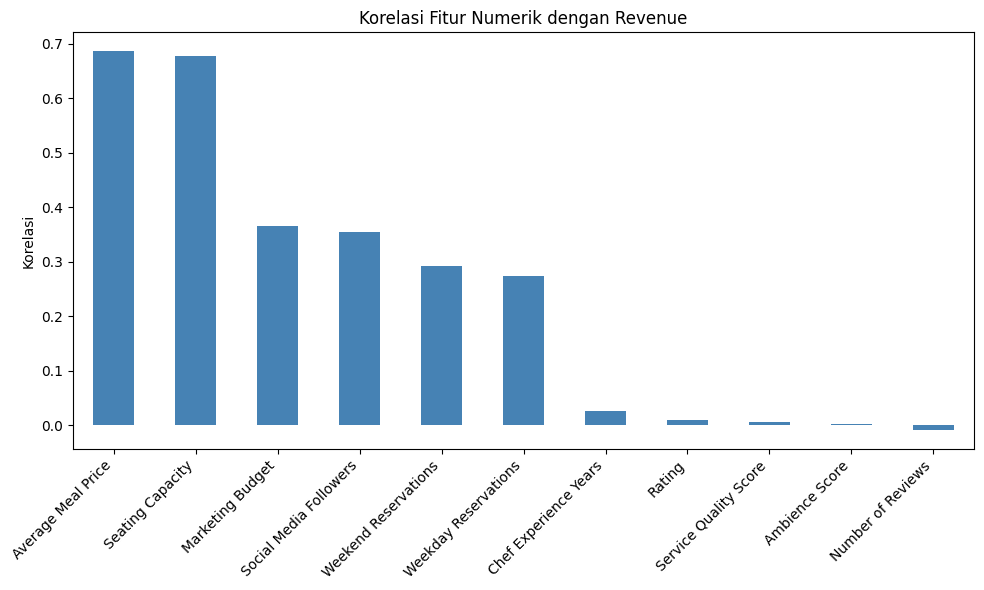


Korelasi dengan Revenue:
Revenue                   1.000000
Average Meal Price        0.686365
Seating Capacity          0.677317
Marketing Budget          0.365322
Social Media Followers    0.354466
Weekend Reservations      0.292400
Weekday Reservations      0.273284
Chef Experience Years     0.026899
Rating                    0.009899
Service Quality Score     0.005375
Ambience Score            0.003388
Number of Reviews        -0.008233
Name: Revenue, dtype: float64


In [9]:
# ── Cell 4: Korelasi fitur numerik dengan Revenue ──
num_cols = df.select_dtypes(include='number').columns
corr = df[num_cols].corr()['Revenue'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
corr.drop('Revenue').plot(kind='bar', color='steelblue')
plt.title('Korelasi Fitur Numerik dengan Revenue')
plt.ylabel('Korelasi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/korelasi_fitur.png', dpi=150)
plt.show()

print("\nKorelasi dengan Revenue:")
print(corr)

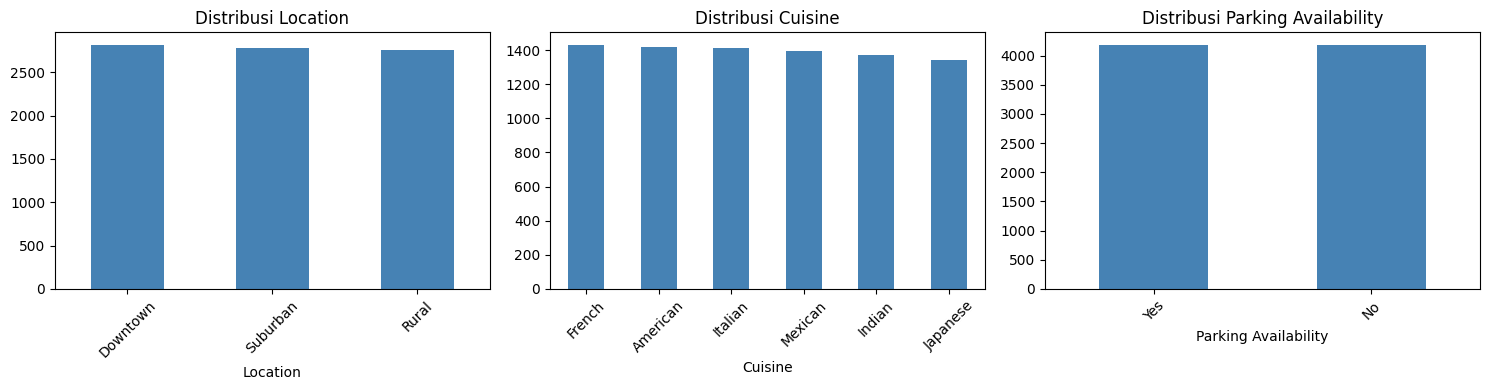

In [11]:
# ── Cell 5: Distribusi kolom kategorikal ──
cat_cols = ['Location', 'Cuisine', 'Parking Availability']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/distribusi_kategorikal.png', dpi=150)
plt.show()

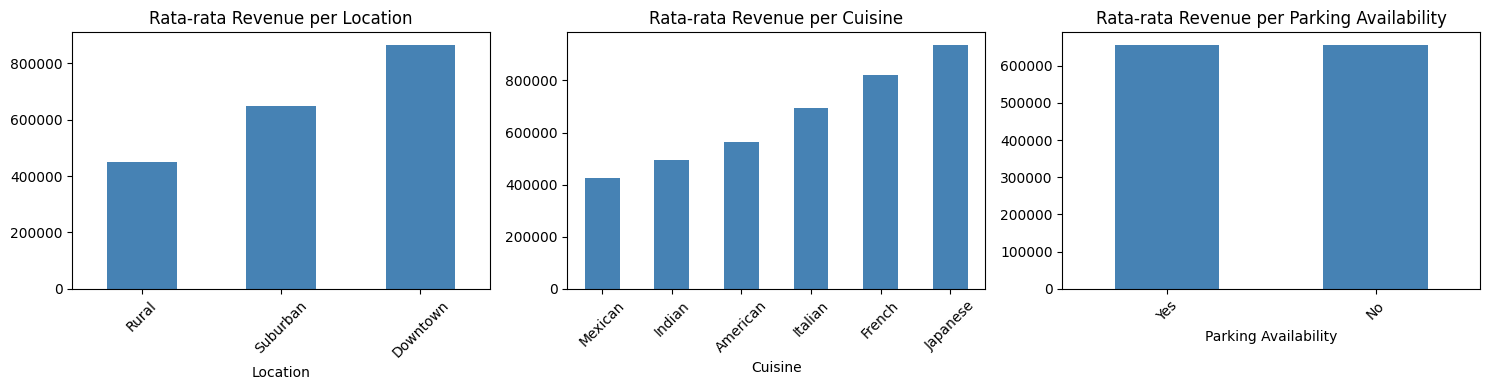

In [12]:
# ── Cell 6: Revenue per kategori ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(cat_cols):
    df.groupby(col)['Revenue'].mean().sort_values().plot(
        kind='bar', ax=axes[i], color='steelblue'
    )
    axes[i].set_title(f'Rata-rata Revenue per {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/revenue_per_kategori.png', dpi=150)
plt.show()